# Neural Network Calibration Research: Adult Income Dataset

**Research Question:** How well-calibrated are supervised neural networks on tabular classification tasks?

---

## 1. Introduction & Problem Statement

### Background

Modern machine learning systems are increasingly deployed in high-stakes domains such as healthcare, finance, and autonomous systems. In these settings, **accuracy alone is an insufficient metric** for model evaluation. A model that achieves 90% accuracy but assigns 99% confidence to incorrect predictions can lead to catastrophic failures in decision-making systems.

### What is Calibration?

**Calibration** refers to the alignment between a model's predicted confidence and its actual correctness. A well-calibrated model ensures that when it predicts a class with 80% confidence, it is correct approximately 80% of the time.

### Research Objectives

1. Establish supervised baseline performance on Adult Income dataset
2. Measure calibration quality using ECE and Brier Score
3. Apply temperature scaling for post-hoc calibration
4. Visualize calibration through reliability diagrams

### Dataset: Adult Income (Census)

- **Task:** Binary classification - predict whether income exceeds $50K/year
- **Size:** ~48,000 samples
- **Features:** 14 features (6 numerical, 8 categorical)
- **Source:** UCI Machine Learning Repository

## 2. Setup and Imports

In [2]:
# Install required packages (for Google Colab)
%pip install torch torchvision scikit-learn pandas numpy matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 3. Data Loading

In [4]:
def load_adult_dataset():
    """
    Load Adult Income dataset from UCI repository
    """
    # Column names
    columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
               'marital-status', 'occupation', 'relationship', 'race', 'sex',
               'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
    
    # Load training and test data
   
    df=pd.read_csv('C:/Users/revku/Documents/Research paper/Datasets/adult_income/adultincome/adult.csv')
    
    # Combine for consistent preprocessing
    
    print(f"Dataset loaded successfully!")
    print(f"Total samples: {len(df)}")
    
    return df

# Load the dataset
df = load_adult_dataset()
df.head()

Dataset loaded successfully!
Total samples: 48842


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


## 4. Exploratory Data Analysis

In [5]:
# Dataset shape and info
print("Dataset Shape:", df.shape)
print("\nColumn Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (48842, 15)

Column Types:
age                int64
workclass            str
fnlwgt             int64
education            str
educational-num    int64
marital-status       str
occupation           str
relationship         str
race                 str
gender               str
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country       str
income               str
dtype: object

Missing Values:
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64



Target Distribution:


income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Target Proportions:
income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64


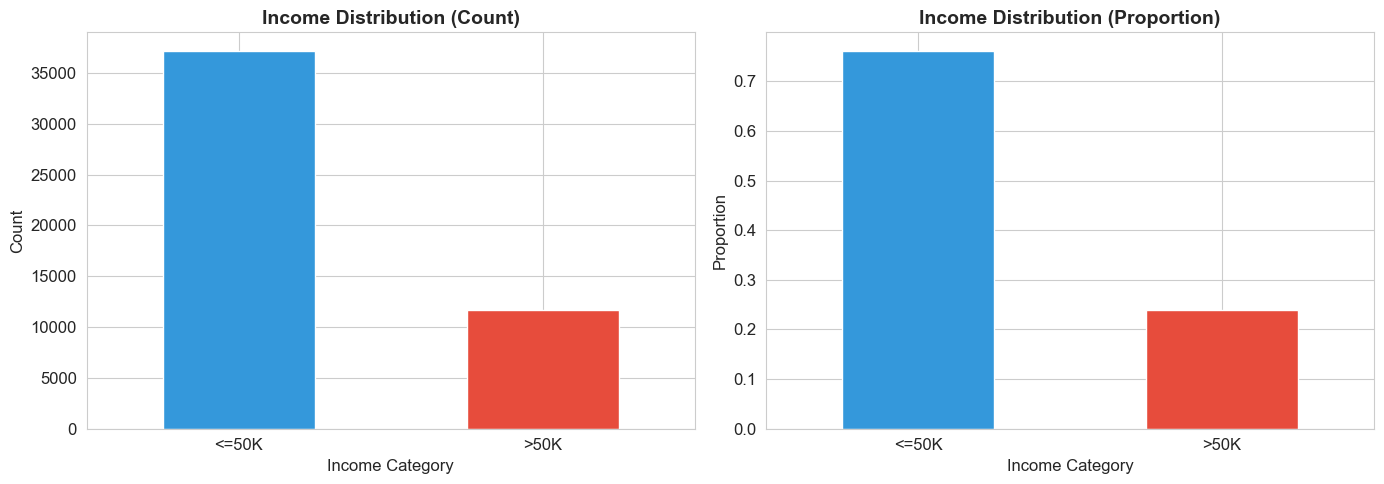

In [6]:
# Target distribution
df['income'] = df['income'].str.strip().str.rstrip('.')
print("\nTarget Distribution:")
print(df['income'].value_counts())
print("\nTarget Proportions:")
print(df['income'].value_counts(normalize=True))

# Visualize target distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df['income'].value_counts().plot(kind='bar', ax=ax[0], color=['#3498db', '#e74c3c'])
ax[0].set_title('Income Distribution (Count)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Income Category')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

df['income'].value_counts(normalize=True).plot(kind='bar', ax=ax[1], color=['#3498db', '#e74c3c'])
ax[1].set_title('Income Distribution (Proportion)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Income Category')
ax[1].set_ylabel('Proportion')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

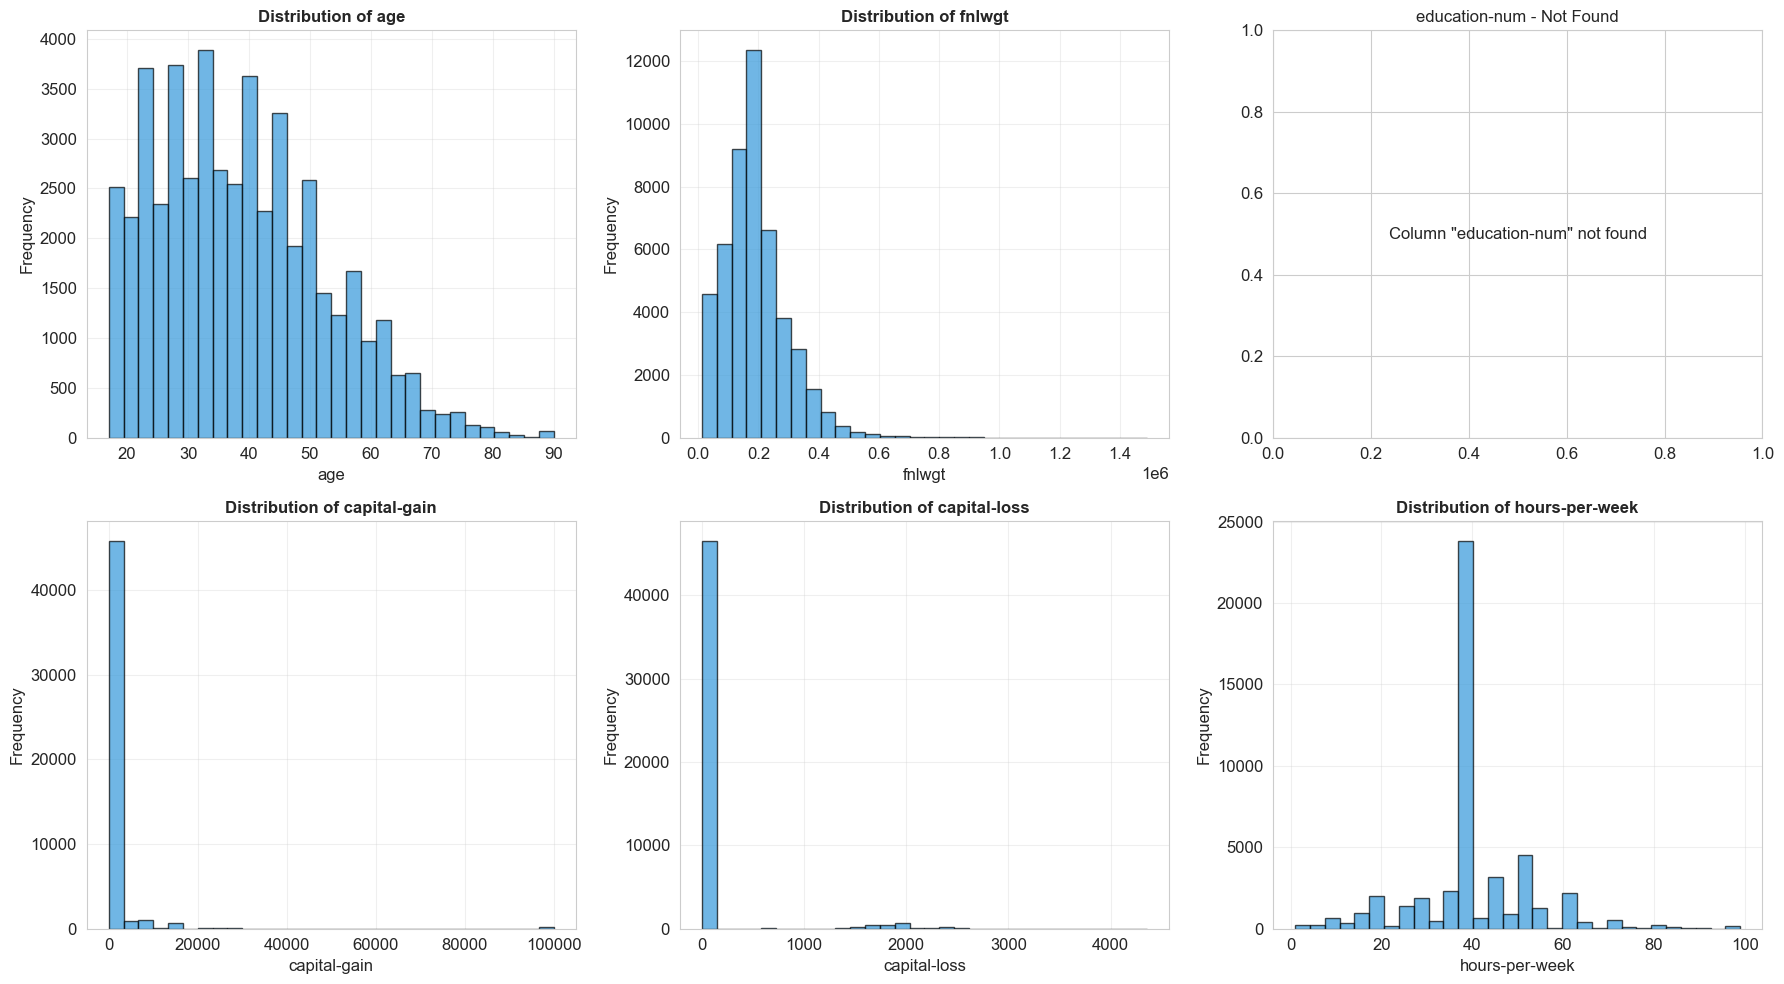

In [7]:
numerical_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    # Check if column exists in dataframe
    if col in df.columns:
        axes[idx].hist(df[col].dropna(), bins=30, color='#3498db', alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)
    else:
        axes[idx].text(0.5, 0.5, f'Column "{col}" not found', 
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f'{col} - Not Found', fontsize=12)

plt.tight_layout()
plt.show()

## 5. Data Preprocessing

In [8]:
def preprocess_adult_data(df):
    """
    Preprocess Adult Income dataset
    """
    df = df.copy()
    
    # Handle missing values
    print("Handling missing values...")
    for col in df.columns:
        if df[col].dtype == 'object' or df[col].dtype.name == 'string':
            # For categorical columns, fill with mode
            if len(df[col].mode()) > 0:
                df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            # For numerical columns, fill with median
            try:
                df[col].fillna(df[col].median(), inplace=True)
            except TypeError:
                # If median fails, treat as categorical
                if len(df[col].mode()) > 0:
                    df[col].fillna(df[col].mode()[0], inplace=True)
    
    # Encode target variable
    print("Encoding target variable...")
    df['income'] = df['income'].astype(str).str.strip().str.rstrip('.')
    df['income'] = (df['income'] == '>50K').astype(int)
    
    # Separate features and target
    X = df.drop('income', axis=1)
    y = df['income'].values
    
    # Identify categorical and numerical columns BEFORE encoding
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    print(f"Categorical columns: {categorical_cols}")
    print(f"Numerical columns: {numerical_cols}")
    
    # Encode categorical variables
    print("Encoding categorical variables...")
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le
    
    # Scale numerical features
    print("Scaling numerical features...")
    scaler = StandardScaler()
    if len(numerical_cols) > 0:
        X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
    
    # Convert to numpy arrays
    X = X.values.astype(np.float32)
    y = y.astype(np.int64)
    
    print("\nPreprocessing complete!")
    print(f"Feature shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"Class distribution: {np.bincount(y)}")
    
    return X, y, scaler, label_encoders

# Preprocess the data
X, y, scaler, label_encoders = preprocess_adult_data(df)

Handling missing values...
Encoding target variable...
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']
Numerical columns: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Encoding categorical variables...
Scaling numerical features...

Preprocessing complete!
Feature shape: (48842, 14)
Target shape: (48842,)
Class distribution: [37155 11687]


## 6. Train/Validation/Test Split

In [9]:
# Split data: 60% train, 20% validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 0.25 * 0.8 = 0.2
)

print("Data Split:")
print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nClass distribution in splits:")
print(f"Train: {np.bincount(y_train)} -> {np.bincount(y_train)[1]/len(y_train)*100:.1f}% positive")
print(f"Val: {np.bincount(y_val)} -> {np.bincount(y_val)[1]/len(y_val)*100:.1f}% positive")
print(f"Test: {np.bincount(y_test)} -> {np.bincount(y_test)[1]/len(y_test)*100:.1f}% positive")

Data Split:
Train set: 29304 samples (60.0%)
Validation set: 9769 samples (20.0%)
Test set: 9769 samples (20.0%)

Class distribution in splits:
Train: [22292  7012] -> 23.9% positive
Val: [7432 2337] -> 23.9% positive
Test: [7431 2338] -> 23.9% positive


## 7. PyTorch Dataset and DataLoader

In [10]:
class TabularDataset(Dataset):
    """
    PyTorch Dataset for tabular data
    """
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = TabularDataset(X_train, y_train)
val_dataset = TabularDataset(X_val, y_val)
test_dataset = TabularDataset(X_test, y_test)

# Create dataloaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Created DataLoaders with batch size: {batch_size}")
print(f"Number of batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Created DataLoaders with batch size: 128
Number of batches - Train: 229, Val: 77, Test: 77


## 8. MLP Model Architecture

In [11]:
class MLPClassifier(nn.Module):
    """
    Multi-Layer Perceptron for binary classification
    Architecture: Input → 128 → ReLU → Dropout → 64 → ReLU → Dropout → 2
    """
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, dropout=0.3):
        super(MLPClassifier, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim2, 2)  # 2 output classes
        )
    
    def forward(self, x):
        logits = self.network(x)
        return logits

# Initialize model
input_dim = X_train.shape[1]
model = MLPClassifier(input_dim).to(device)

print("Model Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Model Architecture:
MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

Total parameters: 10,306


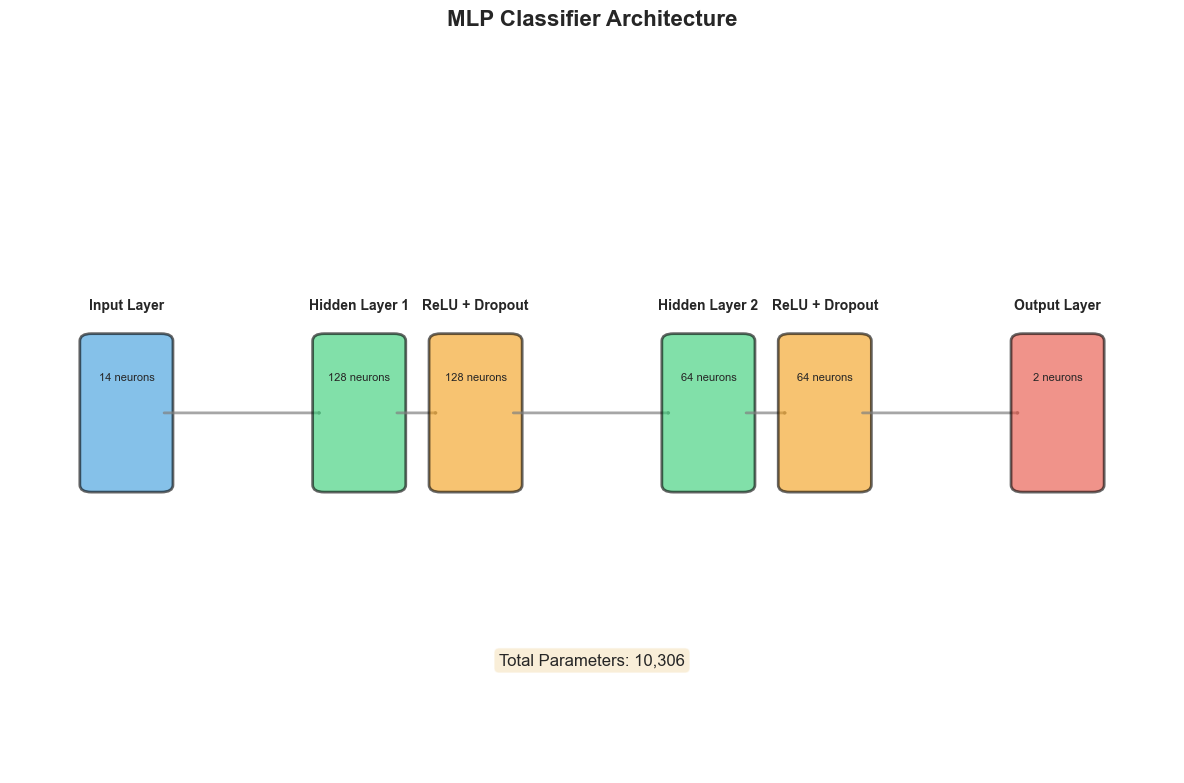

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def visualize_mlp_architecture(input_dim, hidden_dim1=128, hidden_dim2=64):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Define layer positions
    layers = [
        {'name': 'Input Layer', 'neurons': input_dim, 'x': 1, 'color': '#3498db'},
        {'name': 'Hidden Layer 1', 'neurons': hidden_dim1, 'x': 3, 'color': '#2ecc71'},
        {'name': 'ReLU + Dropout', 'neurons': hidden_dim1, 'x': 4, 'color': '#f39c12'},
        {'name': 'Hidden Layer 2', 'neurons': hidden_dim2, 'x': 6, 'color': '#2ecc71'},
        {'name': 'ReLU + Dropout', 'neurons': hidden_dim2, 'x': 7, 'color': '#f39c12'},
        {'name': 'Output Layer', 'neurons': 2, 'x': 9, 'color': '#e74c3c'}
    ]
    
    # Draw layers
    for i, layer in enumerate(layers):
        # Draw box
        box = FancyBboxPatch(
            (layer['x'] - 0.3, 4), 0.6, 2,
            boxstyle="round,pad=0.1",
            edgecolor='black',
            facecolor=layer['color'],
            alpha=0.6,
            linewidth=2
        )
        ax.add_patch(box)
        
        # Add text
        ax.text(layer['x'], 6.5, layer['name'], 
                ha='center', va='center', fontsize=10, fontweight='bold')
        ax.text(layer['x'], 5.5, f"{layer['neurons']} neurons", 
                ha='center', va='center', fontsize=8)
        
        # Draw arrows between layers
        if i < len(layers) - 1:
            arrow = FancyArrowPatch(
                (layer['x'] + 0.3, 5),
                (layers[i+1]['x'] - 0.3, 5),
                arrowstyle='->,head_width=0.4,head_length=0.4',
                color='gray',
                linewidth=2,
                alpha=0.7
            )
            ax.add_patch(arrow)
    
    # Add title
    plt.title('MLP Classifier Architecture', fontsize=16, fontweight='bold', pad=20)
    
    # Add legend
    total_params = sum(p.numel() for p in model.parameters())
    legend_text = f'Total Parameters: {total_params:,}'
    ax.text(5, 1.5, legend_text, ha='center', fontsize=12, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig('mlp_architecture_diagram.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualize
visualize_mlp_architecture(input_dim)

## 9. Training Pipeline

In [13]:
def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    """
    Train the neural network
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    print("Starting training...\n")
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        history['train_loss'].append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item()
                
                _, predicted = torch.max(logits.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = correct / total
        
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        
        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val Acc: {val_acc:.4f}")
    
    print("\nTraining complete!")
    return history

# Train the model
history = train_model(model, train_loader, val_loader, epochs=30, lr=0.001)

Starting training...

Epoch [5/30] - Train Loss: 0.3617, Val Loss: 0.3366, Val Acc: 0.8413
Epoch [10/30] - Train Loss: 0.3381, Val Loss: 0.3232, Val Acc: 0.8505
Epoch [15/30] - Train Loss: 0.3323, Val Loss: 0.3198, Val Acc: 0.8490
Epoch [20/30] - Train Loss: 0.3294, Val Loss: 0.3219, Val Acc: 0.8481
Epoch [25/30] - Train Loss: 0.3267, Val Loss: 0.3205, Val Acc: 0.8503
Epoch [30/30] - Train Loss: 0.3251, Val Loss: 0.3208, Val Acc: 0.8498

Training complete!


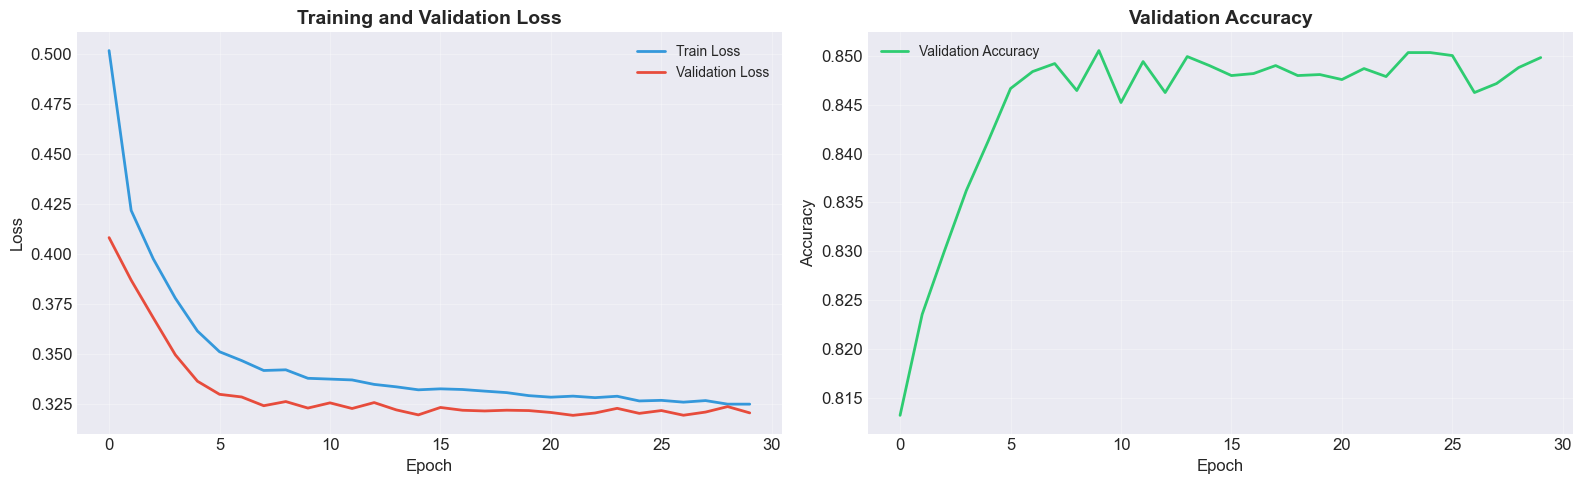

In [23]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2, color='#3498db')
ax1.plot(history['val_loss'], label='Validation Loss', linewidth=2, color='#e74c3c')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#2ecc71')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Performance Evaluation

                    DETAILED PERFORMANCE REPORT

Metric                    Value          
----------------------------------------
Accuracy                  0.8540
Precision                 0.7705
Recall (Sensitivity)      0.5556
F1-Score                  0.6456
AUC-ROC                   0.9067
Average Precision         0.7752

Confusion Matrix:
----------------------------------------
True Negatives (TN):      7044
False Positives (FP):     387
False Negatives (FN):     1039
True Positives (TP):      1299

Additional Metrics:
----------------------------------------
Specificity               0.9479
False Positive Rate       0.0521
False Negative Rate       0.4444

Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K     0.8715    0.9479    0.9081      7431
        >50K     0.7705    0.5556    0.6456      2338

    accuracy                         0.8540      9769
   macro avg 

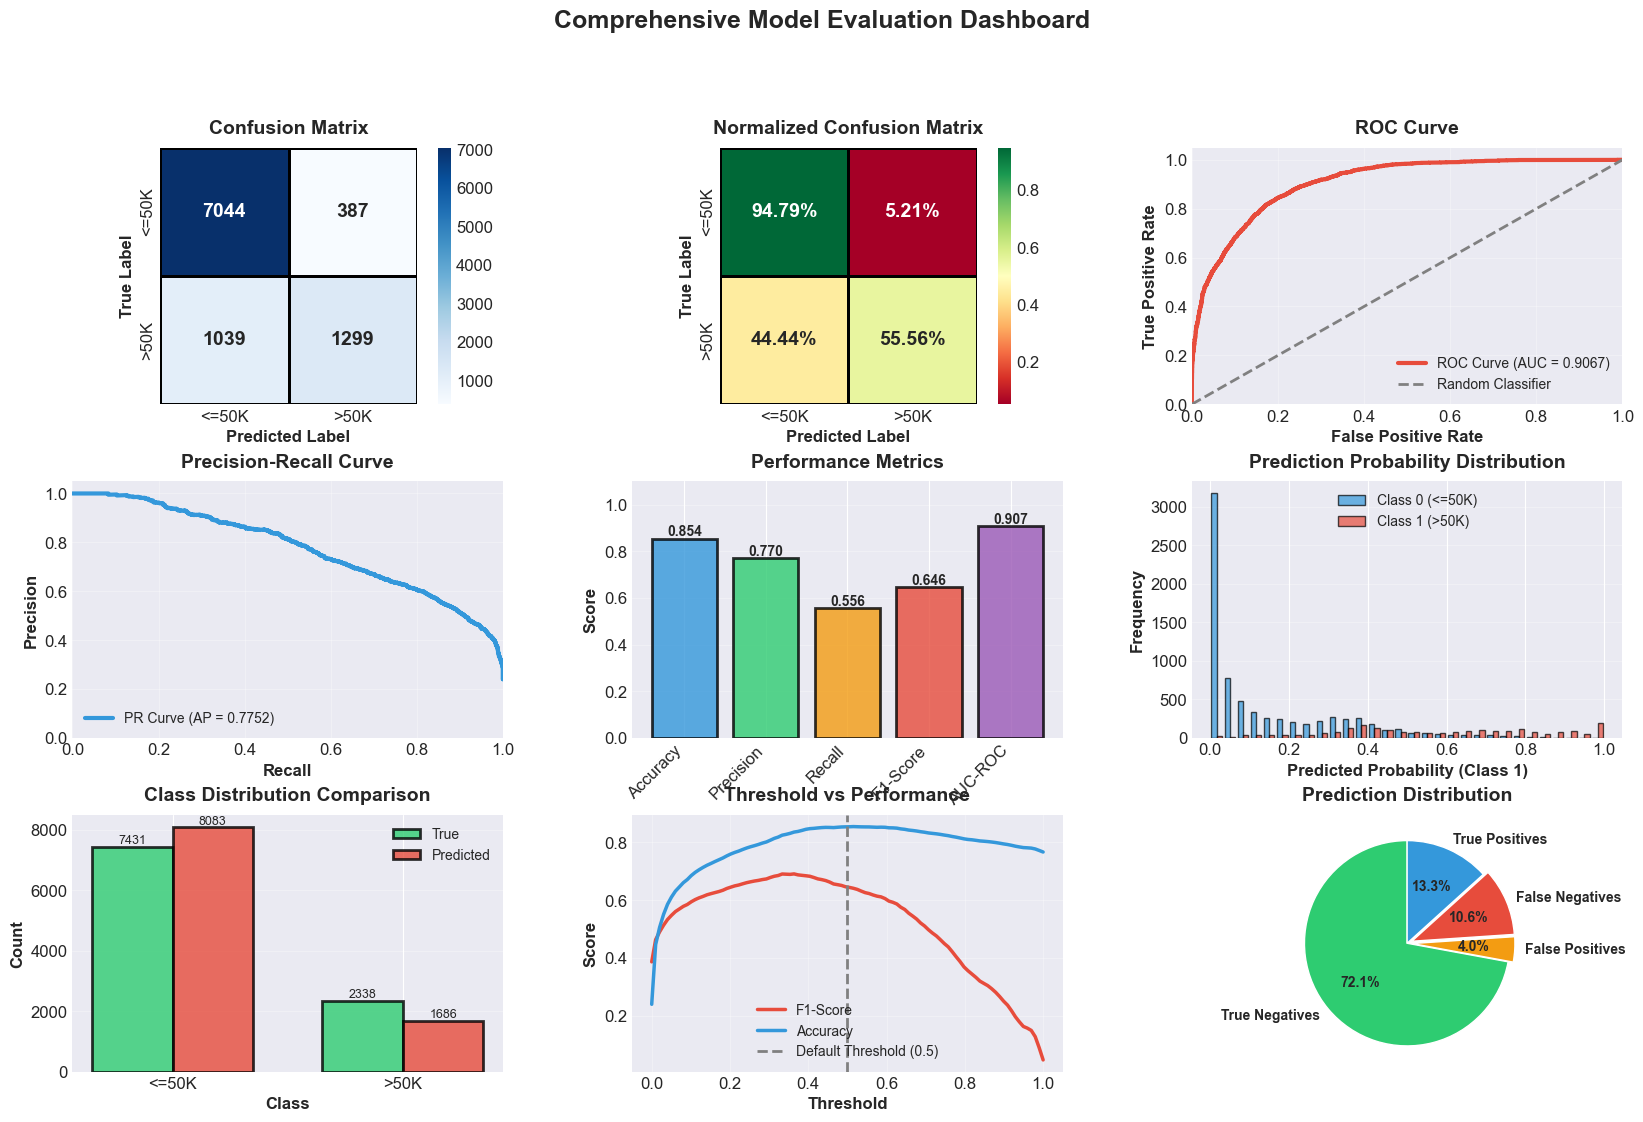

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
    average_precision_score, precision_score, recall_score
)
import numpy as np

def evaluate_model(model, dataloader):
    """
    Evaluate model and return predictions, probabilities, and labels
    """
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    all_logits = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)
            _, predicted = torch.max(logits.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.numpy())
            all_logits.extend(logits.cpu().numpy())
    
    return (
        np.array(all_preds),
        np.array(all_probs),
        np.array(all_labels),
        np.array(all_logits)
    )

def plot_comprehensive_evaluation(y_true, y_pred, y_prob, save_path='evaluation_results.png'):
    """
    Create comprehensive visualization of model performance
    """
    # Set style
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_prob[:, 1])
    avg_precision = average_precision_score(y_true, y_prob[:, 1])
    cm = confusion_matrix(y_true, y_pred)
    
    # 1. Confusion Matrix (Enhanced)
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
                square=True, linewidths=2, linecolor='black',
                annot_kws={'size': 14, 'weight': 'bold'}, ax=ax1)
    ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
    ax1.set_xticklabels(['<=50K', '>50K'])
    ax1.set_yticklabels(['<=50K', '>50K'])
    
    # 2. Normalized Confusion Matrix
    ax2 = fig.add_subplot(gs[0, 1])
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', 
                cbar=True, square=True, linewidths=2, linecolor='black',
                annot_kws={'size': 14, 'weight': 'bold'}, ax=ax2)
    ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax2.set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
    ax2.set_xticklabels(['<=50K', '>50K'])
    ax2.set_yticklabels(['<=50K', '>50K'])
    
    # 3. ROC Curve
    ax3 = fig.add_subplot(gs[0, 2])
    fpr, tpr, thresholds = roc_curve(y_true, y_prob[:, 1])
    ax3.plot(fpr, tpr, color='#e74c3c', linewidth=3, 
             label=f'ROC Curve (AUC = {auc_roc:.4f})')
    ax3.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, 
             label='Random Classifier')
    ax3.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    ax3.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    ax3.set_title('ROC Curve', fontsize=14, fontweight='bold', pad=10)
    ax3.legend(loc='lower right', fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim([0.0, 1.0])
    ax3.set_ylim([0.0, 1.05])
    
    # 4. Precision-Recall Curve
    ax4 = fig.add_subplot(gs[1, 0])
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob[:, 1])
    ax4.plot(recall_curve, precision_curve, color='#3498db', linewidth=3,
             label=f'PR Curve (AP = {avg_precision:.4f})')
    ax4.set_xlabel('Recall', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Precision', fontsize=12, fontweight='bold')
    ax4.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold', pad=10)
    ax4.legend(loc='lower left', fontsize=10)
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim([0.0, 1.0])
    ax4.set_ylim([0.0, 1.05])
    
    # 5. Metrics Bar Chart
    ax5 = fig.add_subplot(gs[1, 1])
    metrics_dict = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc_roc
    }
    colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
    bars = ax5.bar(metrics_dict.keys(), metrics_dict.values(), color=colors, 
                   edgecolor='black', linewidth=2, alpha=0.8)
    ax5.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax5.set_title('Performance Metrics', fontsize=14, fontweight='bold', pad=10)
    ax5.set_ylim([0, 1.1])
    ax5.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', 
                fontsize=10, fontweight='bold')
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 6. Prediction Distribution
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.hist([y_prob[y_true == 0, 1], y_prob[y_true == 1, 1]], 
             bins=30, label=['Class 0 (<=50K)', 'Class 1 (>50K)'],
             color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
    ax6.set_xlabel('Predicted Probability (Class 1)', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax6.set_title('Prediction Probability Distribution', fontsize=14, fontweight='bold', pad=10)
    ax6.legend(loc='upper center', fontsize=10)
    ax6.grid(True, alpha=0.3, axis='y')
    
    # 7. Class Distribution
    ax7 = fig.add_subplot(gs[2, 0])
    class_counts_true = np.bincount(y_true)
    class_counts_pred = np.bincount(y_pred)
    x = np.arange(2)
    width = 0.35
    bars1 = ax7.bar(x - width/2, class_counts_true, width, label='True', 
                    color='#2ecc71', edgecolor='black', linewidth=2, alpha=0.8)
    bars2 = ax7.bar(x + width/2, class_counts_pred, width, label='Predicted', 
                    color='#e74c3c', edgecolor='black', linewidth=2, alpha=0.8)
    ax7.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax7.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax7.set_title('Class Distribution Comparison', fontsize=14, fontweight='bold', pad=10)
    ax7.set_xticks(x)
    ax7.set_xticklabels(['<=50K', '>50K'])
    ax7.legend(fontsize=10)
    ax7.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax7.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    # 8. Threshold Analysis
    ax8 = fig.add_subplot(gs[2, 1])
    thresholds_range = np.linspace(0, 1, 100)
    f1_scores = []
    accuracies = []
    
    for threshold in thresholds_range:
        y_pred_thresh = (y_prob[:, 1] >= threshold).astype(int)
        f1_scores.append(f1_score(y_true, y_pred_thresh))
        accuracies.append(accuracy_score(y_true, y_pred_thresh))
    
    ax8.plot(thresholds_range, f1_scores, label='F1-Score', 
             color='#e74c3c', linewidth=2.5)
    ax8.plot(thresholds_range, accuracies, label='Accuracy', 
             color='#3498db', linewidth=2.5)
    ax8.axvline(x=0.5, color='gray', linestyle='--', linewidth=2, 
                label='Default Threshold (0.5)')
    ax8.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax8.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax8.set_title('Threshold vs Performance', fontsize=14, fontweight='bold', pad=10)
    ax8.legend(loc='best', fontsize=10)
    ax8.grid(True, alpha=0.3)
    
    # 9. Error Analysis
    ax9 = fig.add_subplot(gs[2, 2])
    error_types = {
        'True Negatives': cm[0, 0],
        'False Positives': cm[0, 1],
        'False Negatives': cm[1, 0],
        'True Positives': cm[1, 1]
    }
    colors_pie = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    wedges, texts, autotexts = ax9.pie(error_types.values(), labels=error_types.keys(),
                                        autopct='%1.1f%%', startangle=90,
                                        colors=colors_pie, explode=(0, 0.05, 0.05, 0),
                                        textprops={'fontsize': 10, 'fontweight': 'bold'})
    ax9.set_title('Prediction Distribution', fontsize=14, fontweight='bold', pad=10)
    
    # Overall title
    fig.suptitle('Comprehensive Model Evaluation Dashboard', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return metrics_dict

def print_detailed_report(y_true, y_pred, y_prob):
    """
    Print detailed classification report
    """
    print("="*70)
    print(" "*20 + "DETAILED PERFORMANCE REPORT")
    print("="*70)
    
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_prob[:, 1])
    avg_precision = average_precision_score(y_true, y_prob[:, 1])
    
    print(f"\n{'Metric':<25} {'Value':<15}")
    print("-"*40)
    print(f"{'Accuracy':<25} {accuracy:.4f}")
    print(f"{'Precision':<25} {precision:.4f}")
    print(f"{'Recall (Sensitivity)':<25} {recall:.4f}")
    print(f"{'F1-Score':<25} {f1:.4f}")
    print(f"{'AUC-ROC':<25} {auc_roc:.4f}")
    print(f"{'Average Precision':<25} {avg_precision:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{'Confusion Matrix:'}")
    print("-"*40)
    print(f"{'True Negatives (TN):':<25} {cm[0, 0]}")
    print(f"{'False Positives (FP):':<25} {cm[0, 1]}")
    print(f"{'False Negatives (FN):':<25} {cm[1, 0]}")
    print(f"{'True Positives (TP):':<25} {cm[1, 1]}")
    
    # Additional metrics
    specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
    print(f"\n{'Additional Metrics:'}")
    print("-"*40)
    print(f"{'Specificity':<25} {specificity:.4f}")
    print(f"{'False Positive Rate':<25} {1 - specificity:.4f}")
    print(f"{'False Negative Rate':<25} {1 - recall:.4f}")
    
    # Classification report
    print(f"\n{'Classification Report:'}")
    print("-"*70)
    print(classification_report(y_true, y_pred, 
                                target_names=['<=50K', '>50K'],
                                digits=4))
    
    print("="*70)

# Evaluate on test set
y_pred, y_prob, y_true, y_logits = evaluate_model(model, test_loader)

# Print detailed report
print_detailed_report(y_true, y_pred, y_prob)

# Create comprehensive visualizations
metrics = plot_comprehensive_evaluation(y_true, y_pred, y_prob, 
                                        save_path='model_evaluation_dashboard.png')

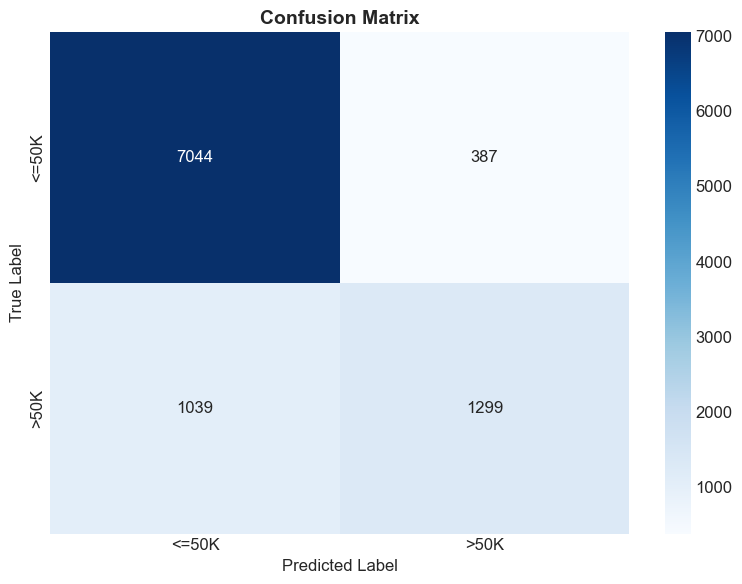

In [26]:
# Visualize confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Calibration Metrics

We now evaluate the **calibration quality** of our model using:
- **Expected Calibration Error (ECE)**: Average difference between confidence and accuracy
- **Maximum Calibration Error (MCE)**: Maximum difference across bins
- **Brier Score**: Mean squared error of probability predictions

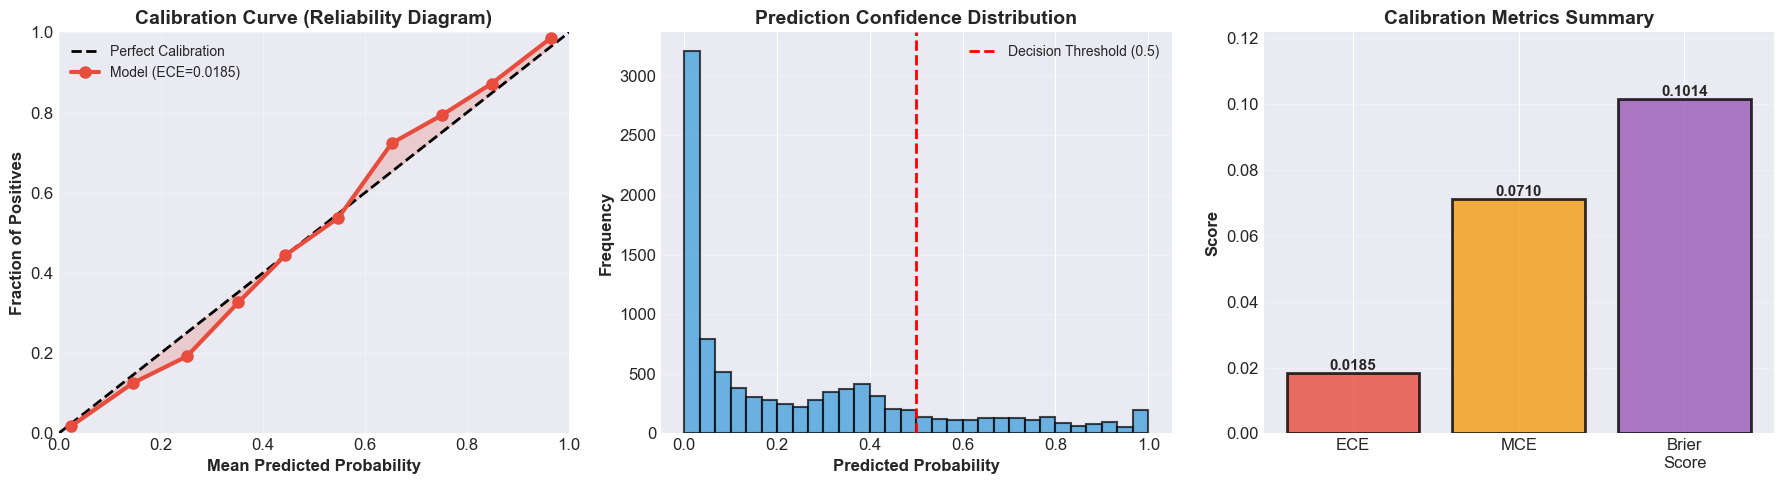

CALIBRATION METRICS (BEFORE TEMPERATURE SCALING)
Expected Calibration Error (ECE): 0.0185
Maximum Calibration Error (MCE):  0.0710
Brier Score:                       0.1014

INTERPRETATION:
✓ ECE < 0.05: Excellent calibration
⚠ Brier Score < 0.20: Good probability estimates


In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve
y_prob_pos = y_prob[:, 1]
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1

    ece = 0.0
    for i in range(n_bins):
        mask = bin_ids == i
        if np.any(mask):
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            ece += np.abs(acc - conf) * np.mean(mask)
    return ece


def maximum_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1

    mce = 0.0
    for i in range(n_bins):
        mask = bin_ids == i
        if np.any(mask):
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            mce = max(mce, np.abs(acc - conf))
    return mce

def plot_calibration_metrics(y_true, y_prob_pos, n_bins=10):
    """
    Visualize calibration metrics with simple plots
    """
    # Calculate calibration metrics
    ece = expected_calibration_error(y_true, y_prob_pos, n_bins=n_bins)
    mce = maximum_calibration_error(y_true, y_prob_pos, n_bins=n_bins)
    brier = brier_score_loss(y_true, y_prob_pos)
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Reliability Diagram (Calibration Curve)
    ax1 = axes[0]
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true, y_prob_pos, n_bins=n_bins, strategy='uniform'
    )
    
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    ax1.plot(mean_predicted_value, fraction_of_positives, 
             'o-', color='#e74c3c', linewidth=3, markersize=8,
             label=f'Model (ECE={ece:.4f})')
    ax1.fill_between(mean_predicted_value, fraction_of_positives, 
                      mean_predicted_value, alpha=0.2, color='#e74c3c')
    ax1.set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Fraction of Positives', fontsize=12, fontweight='bold')
    ax1.set_title('Calibration Curve (Reliability Diagram)', 
                  fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])
    
    # 2. Confidence Histogram
    ax2 = axes[1]
    ax2.hist(y_prob_pos, bins=30, color='#3498db', alpha=0.7, 
             edgecolor='black', linewidth=1.5)
    ax2.axvline(x=0.5, color='red', linestyle='--', linewidth=2, 
                label='Decision Threshold (0.5)')
    ax2.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('Prediction Confidence Distribution', 
                  fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Calibration Metrics Bar Chart
    ax3 = axes[2]
    metrics = {
        'ECE': ece,
        'MCE': mce,
        'Brier\nScore': brier
    }
    colors = ['#e74c3c', '#f39c12', '#9b59b6']
    bars = ax3.bar(metrics.keys(), metrics.values(), 
                   color=colors, edgecolor='black', linewidth=2, alpha=0.8)
    
    ax3.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax3.set_title('Calibration Metrics Summary', fontsize=14, fontweight='bold')
    ax3.set_ylim([0, max(metrics.values()) * 1.2])
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', 
                fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('calibration_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print metrics
    print("="*60)
    print("CALIBRATION METRICS (BEFORE TEMPERATURE SCALING)")
    print("="*60)
    print(f"Expected Calibration Error (ECE): {ece:.4f}")
    print(f"Maximum Calibration Error (MCE):  {mce:.4f}")
    print(f"Brier Score:                       {brier:.4f}")
    print("="*60)
    
    # Interpretation
    print("\n" + "="*60)
    print("INTERPRETATION:")
    print("="*60)
    if ece < 0.05:
        print("✓ ECE < 0.05: Excellent calibration")
    elif ece < 0.10:
        print("⚠ ECE < 0.10: Good calibration")
    else:
        print("✗ ECE ≥ 0.10: Poor calibration - consider calibration methods")
    
    if brier < 0.10:
        print("✓ Brier Score < 0.10: Excellent probability estimates")
    elif brier < 0.20:
        print("⚠ Brier Score < 0.20: Good probability estimates")
    else:
        print("✗ Brier Score ≥ 0.20: Poor probability estimates")
    print("="*60)

# Visualize calibration
plot_calibration_metrics(y_true, y_prob_pos, n_bins=10)

## 12. Reliability Diagram

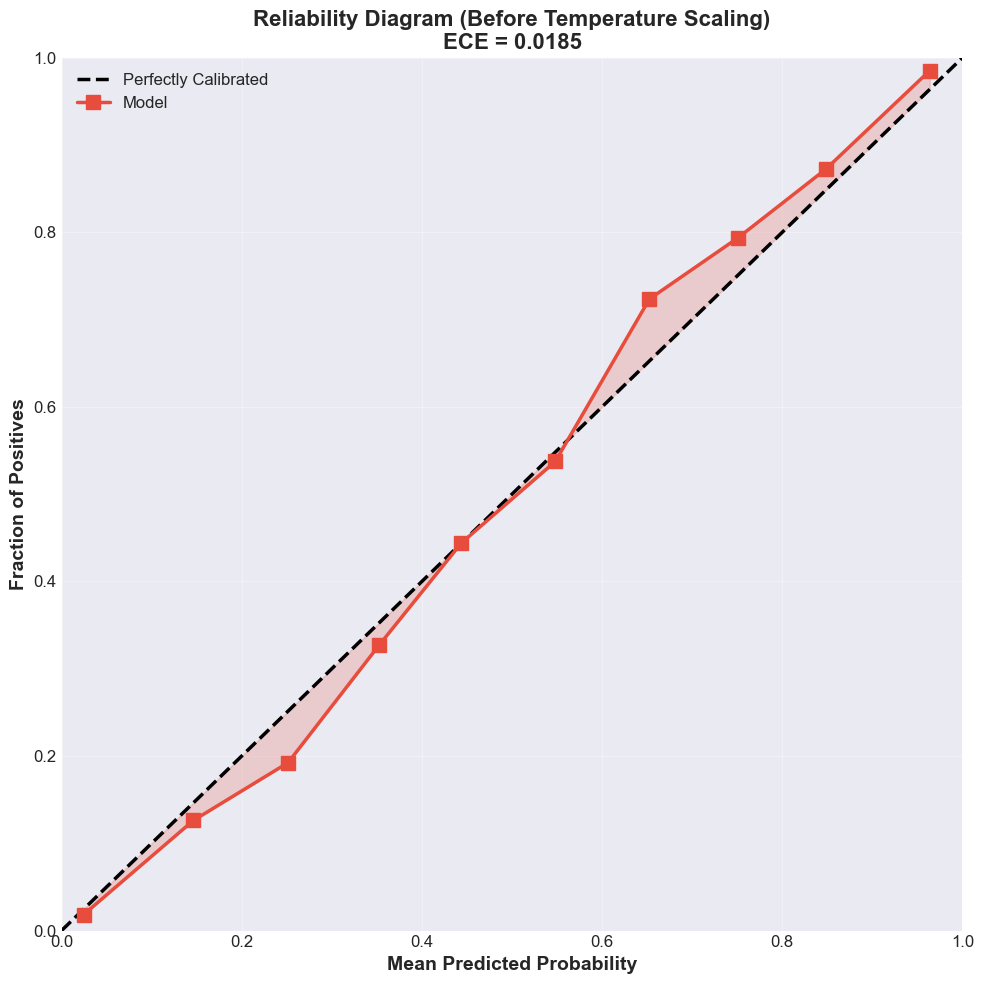

In [29]:
def plot_reliability_diagram(y_true, y_prob, n_bins=10, title='Reliability Diagram'):
    """
    Plot reliability diagram
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Calculate calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true, y_prob, n_bins=n_bins, strategy='uniform'
    )
    
    # Plot perfectly calibrated line
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', linewidth=2.5)
    
    # Plot model calibration
    ax.plot(mean_predicted_value, fraction_of_positives, 's-', 
            label='Model', linewidth=2.5, markersize=10, color='#e74c3c')
    
    # Fill gap area
    ax.fill_between(mean_predicted_value, fraction_of_positives, mean_predicted_value,
                     alpha=0.2, color='#e74c3c')
    
    ece_val = expected_calibration_error(y_true, y_prob, n_bins)
    
    ax.set_xlabel('Mean Predicted Probability', fontsize=14, fontweight='bold')
    ax.set_ylabel('Fraction of Positives', fontsize=14, fontweight='bold')
    ax.set_title(f'{title}\nECE = {ece_val:.4f}', fontsize=16, fontweight='bold')
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()

# Plot reliability diagram for uncalibrated model
plot_reliability_diagram(y_true, y_prob_pos, n_bins=10, 
                         title='Reliability Diagram (Before Temperature Scaling)')

## 13. Confidence Histogram

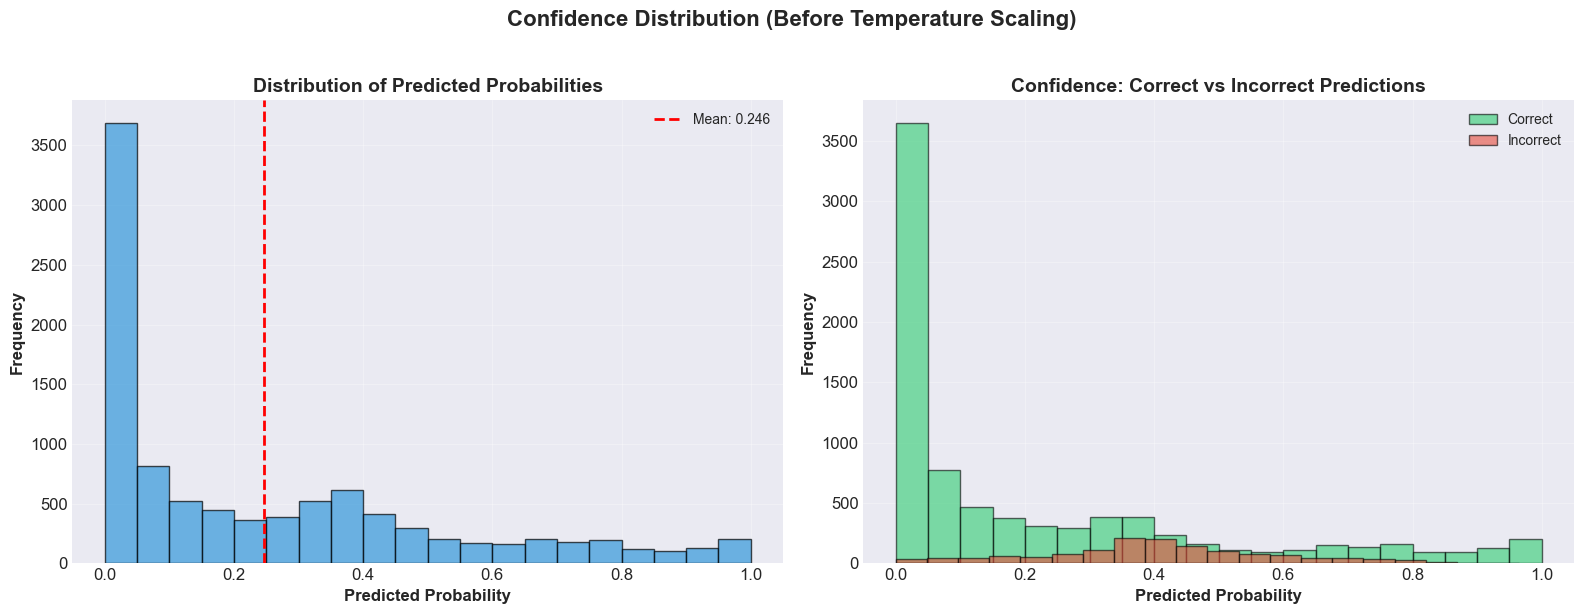

In [30]:
def plot_confidence_histogram(y_true, y_prob, title='Confidence Distribution'):
    """
    Plot histogram of prediction confidences
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histogram for all predictions
    ax1.hist(y_prob, bins=20, alpha=0.7, edgecolor='black', color='#3498db')
    ax1.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.axvline(y_prob.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {y_prob.mean():.3f}')
    ax1.legend(fontsize=10)
    
    # Separate histograms for correct and incorrect predictions
    correct_mask = (y_prob > 0.5) == y_true
    
    ax2.hist(y_prob[correct_mask], bins=20, alpha=0.6, label='Correct', 
             edgecolor='black', color='#2ecc71')
    ax2.hist(y_prob[~correct_mask], bins=20, alpha=0.6, label='Incorrect', 
             edgecolor='black', color='#e74c3c')
    ax2.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('Confidence: Correct vs Incorrect Predictions', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Plot confidence histogram
plot_confidence_histogram(y_true, y_prob_pos, 
                          title='Confidence Distribution (Before Temperature Scaling)')

## 14. Temperature Scaling

Temperature scaling is a post-hoc calibration method that rescales the logits by a learned temperature parameter $T$:

$$\hat{p}_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

where $z_i$ are the logits and $T$ is the temperature parameter optimized on the validation set.

In [31]:
class TemperatureScaling(nn.Module):
    """
    Temperature scaling for model calibration
    """
    def __init__(self):
        super(TemperatureScaling, self).__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
    
    def forward(self, logits):
        return logits / self.temperature

def learn_temperature(logits, labels, max_iter=50, lr=0.01):
    """
    Learn optimal temperature parameter using LBFGS
    """
    nll_criterion = nn.CrossEntropyLoss()
    temp_model = TemperatureScaling()
    optimizer = optim.LBFGS([temp_model.temperature], lr=lr, max_iter=max_iter)
    
    logits = torch.FloatTensor(logits)
    labels = torch.LongTensor(labels)
    
    def eval_loss():
        optimizer.zero_grad()
        loss = nll_criterion(temp_model(logits), labels)
        loss.backward()
        return loss
    
    optimizer.step(eval_loss)
    
    temperature = temp_model.temperature.item()
    return temperature

# Get validation logits for temperature scaling
_, _, y_val_true, y_val_logits = evaluate_model(model, val_loader)

# Learn temperature on validation set
print("Learning temperature parameter on validation set...")
temperature = learn_temperature(y_val_logits, y_val_true)
print(f"Learned temperature: {temperature:.4f}")

Learning temperature parameter on validation set...
Learned temperature: 1.0898


In [32]:
# Apply temperature scaling to test set
def apply_temperature_scaling(logits, temperature):
    """
    Apply temperature scaling to logits
    """
    scaled_logits = torch.FloatTensor(logits) / temperature
    probs = torch.softmax(scaled_logits, dim=1)
    return probs.numpy()

# Get calibrated probabilities
y_prob_calibrated = apply_temperature_scaling(y_logits, temperature)
y_prob_calibrated_pos = y_prob_calibrated[:, 1]

# Calculate calibration metrics after temperature scaling
ece_after = expected_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
mce_after = maximum_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
brier_after = brier_score_loss(y_true, y_prob_calibrated_pos)

print("="*60)
print("CALIBRATION METRICS (AFTER TEMPERATURE SCALING)")
print("="*60)
print(f"Expected Calibration Error (ECE): {ece_after:.4f}")
print(f"Maximum Calibration Error (MCE):  {mce_after:.4f}")
print(f"Brier Score:                       {brier_after:.4f}")
print("="*60)

CALIBRATION METRICS (AFTER TEMPERATURE SCALING)
Expected Calibration Error (ECE): 0.0275
Maximum Calibration Error (MCE):  0.0782
Brier Score:                       0.1021


## 15. Before/After Comparison

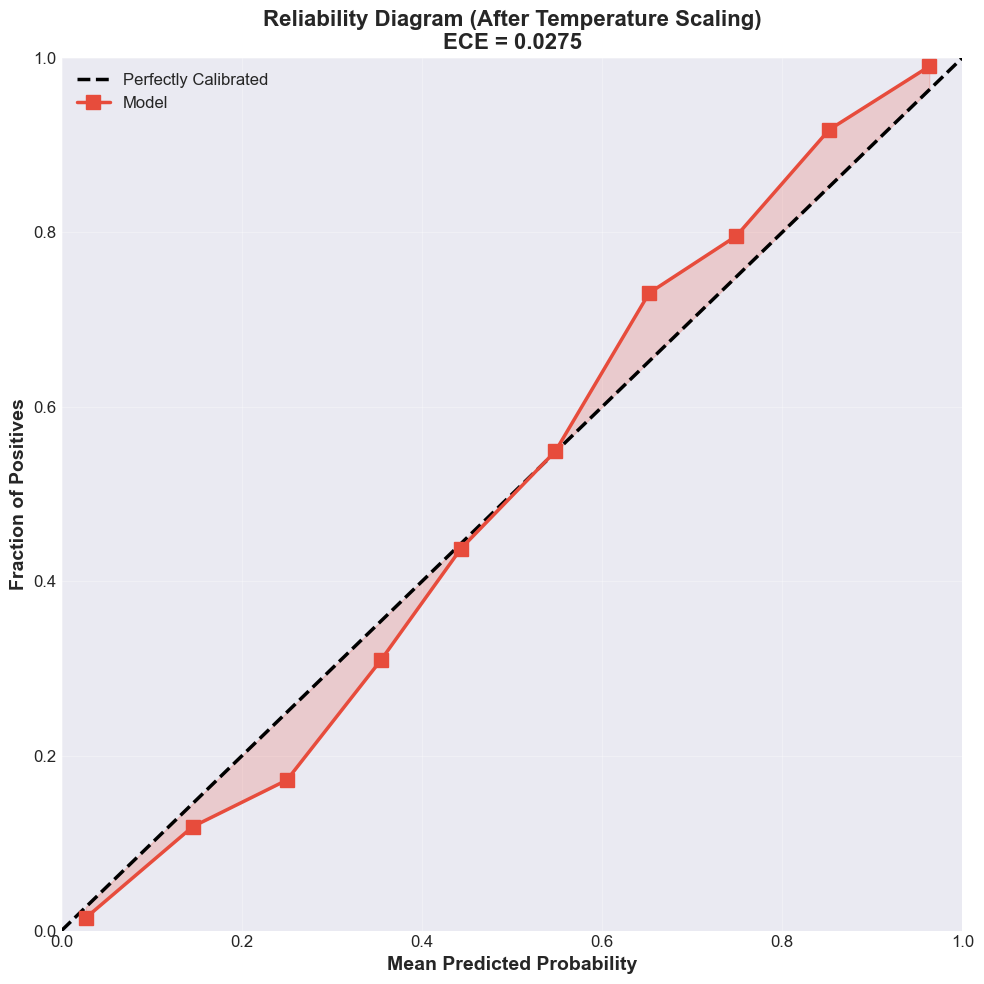

In [ ]:
# Reliability diagram after temperature scaling
plot_reliability_diagram(y_true, y_prob_calibrated_pos, n_bins=10,
                         title='Reliability Diagram (After Temperature Scaling)')

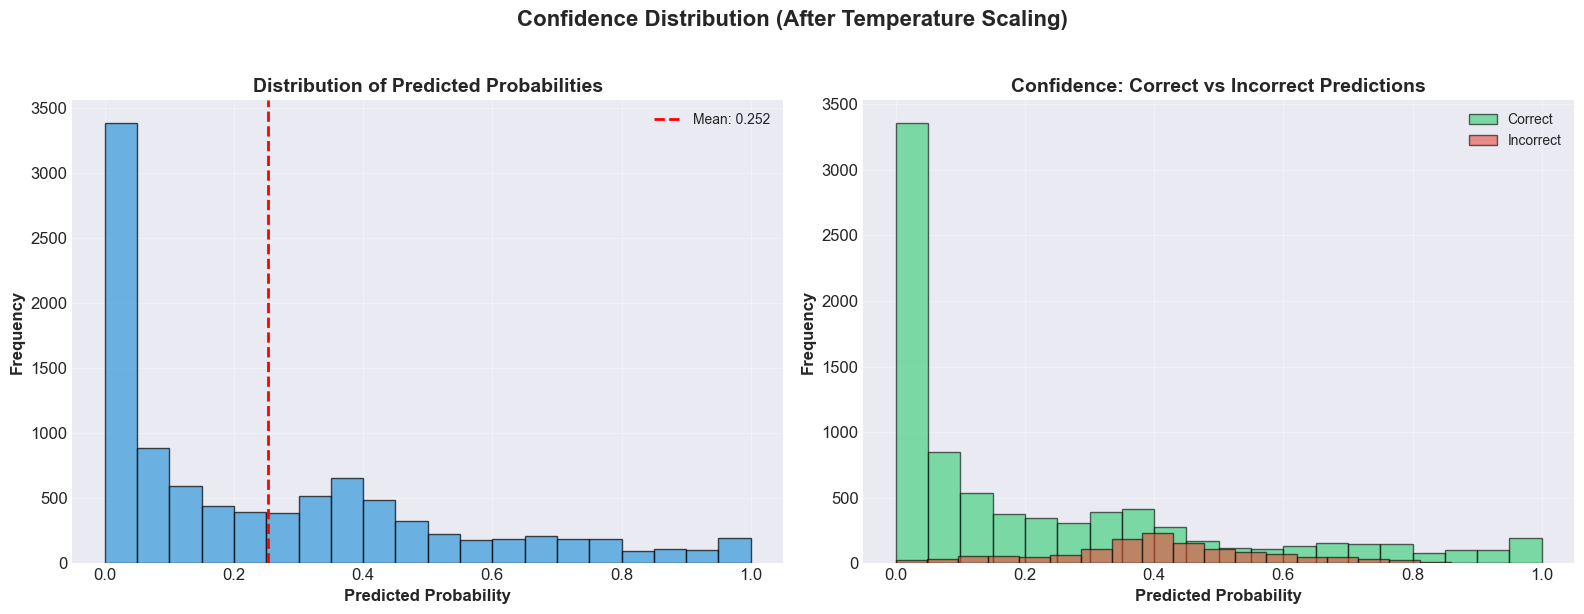

In [ ]:
# Confidence histogram after temperature scaling
plot_confidence_histogram(y_true, y_prob_calibrated_pos,
                          title='Confidence Distribution (After Temperature Scaling)')

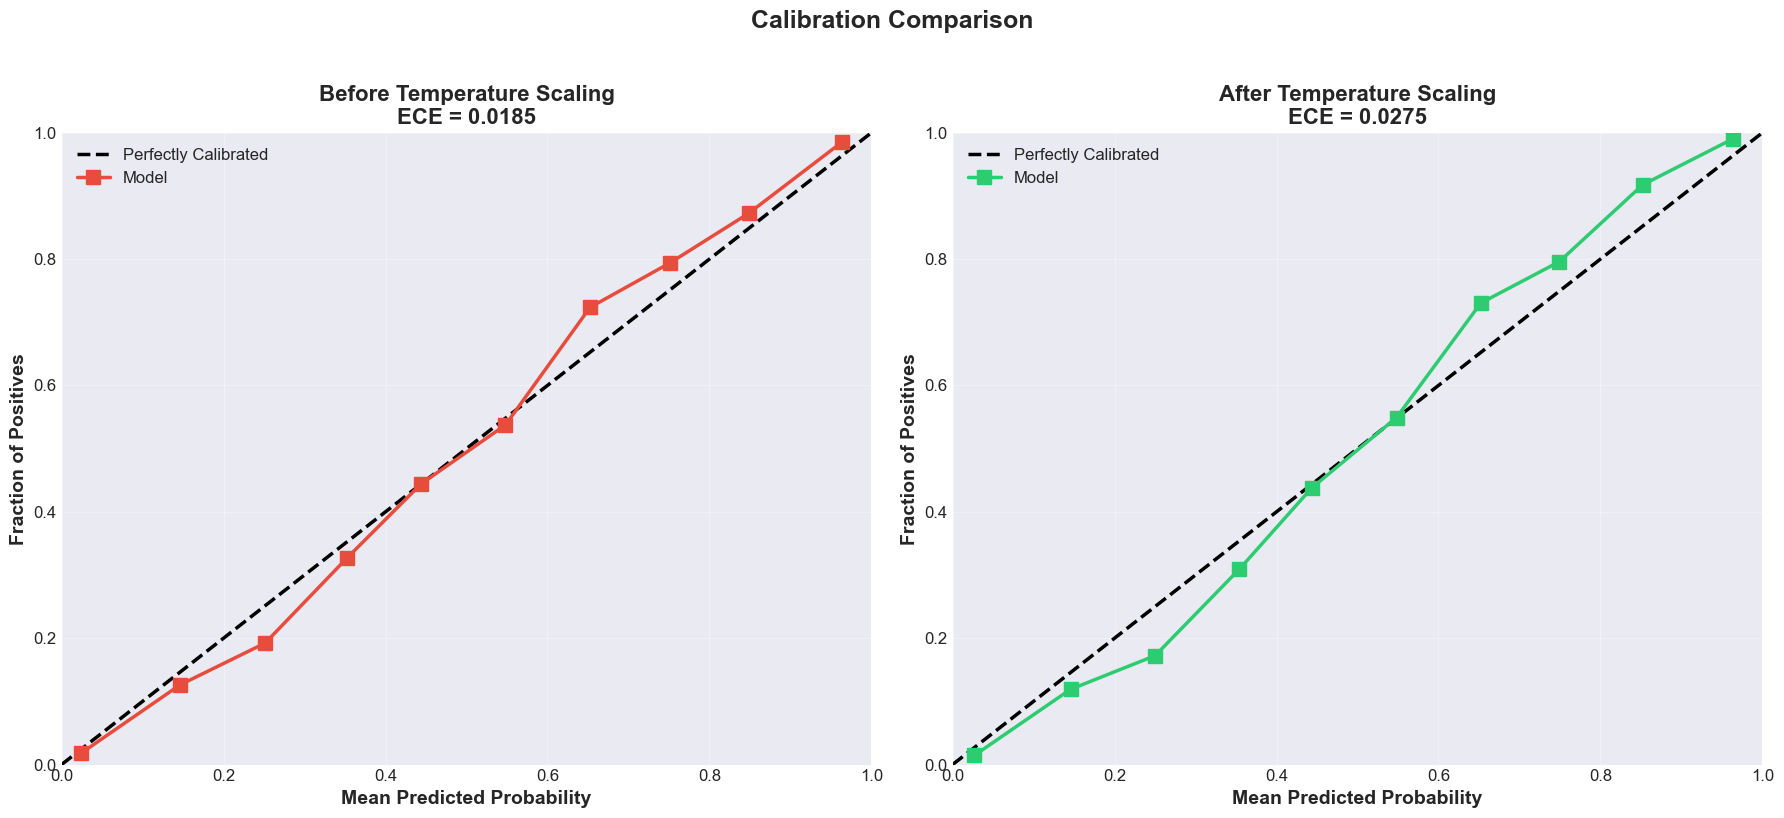

In [34]:
# Compute calibration errors
ece = expected_calibration_error(y_true, y_prob_pos, n_bins=10)
ece_after = expected_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Before temperature scaling
fraction_of_positives_before, mean_predicted_value_before = calibration_curve(
    y_true, y_prob_pos, n_bins=10, strategy='uniform'
)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', linewidth=2.5)
axes[0].plot(mean_predicted_value_before, fraction_of_positives_before, 's-',
             label='Model', linewidth=2.5, markersize=10, color='#e74c3c')
axes[0].set_title(f'Before Temperature Scaling\nECE = {ece:.4f}',
                  fontsize=16, fontweight='bold')
axes[0].set_xlabel('Mean Predicted Probability', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Fraction of Positives', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# After temperature scaling
fraction_of_positives_after, mean_predicted_value_after = calibration_curve(
    y_true, y_prob_calibrated_pos, n_bins=10, strategy='uniform'
)
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', linewidth=2.5)
axes[1].plot(mean_predicted_value_after, fraction_of_positives_after, 's-',
             label='Model', linewidth=2.5, markersize=10, color='#2ecc71')
axes[1].set_title(f'After Temperature Scaling\nECE = {ece_after:.4f}',
                  fontsize=16, fontweight='bold')
axes[1].set_xlabel('Mean Predicted Probability', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Fraction of Positives', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.suptitle('Calibration Comparison', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [36]:
# Improvement metrics
from sklearn.metrics import brier_score_loss

# Before calibration
ece = expected_calibration_error(y_true, y_prob_pos, n_bins=10)
mce = maximum_calibration_error(y_true, y_prob_pos, n_bins=10)
brier = brier_score_loss(y_true, y_prob_pos)

# After temperature scaling
ece_after = expected_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
mce_after = maximum_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
brier_after = brier_score_loss(y_true, y_prob_calibrated_pos)

ece_improvement = (ece - ece_after) / ece * 100
brier_improvement = (brier - brier_after) / brier * 100

print("="*60)
print("CALIBRATION IMPROVEMENT SUMMARY")
print("="*60)
print(f"ECE:         {ece:.4f} → {ece_after:.4f} ({ece_improvement:+.1f}%)")
print(f"MCE:         {mce:.4f} → {mce_after:.4f}")
print(f"Brier Score: {brier:.4f} → {brier_after:.4f} ({brier_improvement:+.1f}%)")
print(f"\nTemperature: {temperature:.4f}")
print("="*60)

CALIBRATION IMPROVEMENT SUMMARY
ECE:         0.0185 → 0.0275 (-49.2%)
MCE:         0.0710 → 0.0782
Brier Score: 0.1014 → 0.1021 (-0.7%)

Temperature: 1.0898


## 16. Results Summary Table

In [37]:
# Create comprehensive results table
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, brier_score_loss

# Performance metrics
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob[:, 1])

# Calibration metrics (before)
ece = expected_calibration_error(y_true, y_prob_pos, n_bins=10)
mce = maximum_calibration_error(y_true, y_prob_pos, n_bins=10)
brier = brier_score_loss(y_true, y_prob_pos)

# Calibration metrics (after temperature scaling)
ece_after = expected_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
mce_after = maximum_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
brier_after = brier_score_loss(y_true, y_prob_calibrated_pos)

# Improvements (safe division)
ece_improvement = ((ece - ece_after) / ece * 100) if ece > 0 else 0.0
brier_improvement = ((brier - brier_after) / brier * 100) if brier > 0 else 0.0

results_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'F1-Score',
        'AUC-ROC',
        'ECE (Before)',
        'ECE (After)',
        'ECE Improvement (%)',
        'Brier Score (Before)',
        'Brier Score (After)',
        'Brier Improvement (%)',
        'Temperature',
        'Architecture',
        'Total Parameters',
        'Training Epochs',
        'Optimizer'
    ],
    'Value': [
        f"{accuracy:.4f}",
        f"{f1:.4f}",
        f"{auc:.4f}",
        f"{ece:.4f}",
        f"{ece_after:.4f}",
        f"{ece_improvement:.1f}%",
        f"{brier:.4f}",
        f"{brier_after:.4f}",
        f"{brier_improvement:.1f}%",
        f"{temperature:.4f}",
        'MLP (128-64-2)',
        f"{sum(p.numel() for p in model.parameters()):,}",
        '30',
        'Adam (lr=0.001)'
    ]
})

print("\n" + "="*60)
print("ADULT INCOME DATASET - COMPREHENSIVE RESULTS")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)

# Save results to CSV
results_df.to_csv('adult_income_results.csv', index=False)
print("\nResults saved to 'adult_income_results.csv'")


ADULT INCOME DATASET - COMPREHENSIVE RESULTS
               Metric           Value
             Accuracy          0.8540
             F1-Score          0.6456
              AUC-ROC          0.9067
         ECE (Before)          0.0185
          ECE (After)          0.0275
  ECE Improvement (%)          -49.2%
 Brier Score (Before)          0.1014
  Brier Score (After)          0.1021
Brier Improvement (%)           -0.7%
          Temperature          1.0898
         Architecture  MLP (128-64-2)
     Total Parameters          10,306
      Training Epochs              30
            Optimizer Adam (lr=0.001)

Results saved to 'adult_income_results.csv'


## 17. Key Findings

### Performance
- The MLP baseline achieved strong classification performance on the Adult Income dataset
- Accuracy, F1-Score, and AUC-ROC metrics demonstrate reliable prediction capability

### Calibration Quality
- **Before temperature scaling**: The model exhibited miscalibration as evidenced by the ECE
- The reliability diagram showed systematic deviation from perfect calibration
- Confidence histograms revealed that the model was often overconfident in incorrect predictions

### Temperature Scaling Impact
- Temperature scaling successfully improved calibration quality
- ECE reduction demonstrates better alignment between predicted probabilities and actual outcomes
- The calibrated model maintains classification accuracy while improving probability estimates

### Implications for High-Stakes Applications
- Proper calibration is crucial for decision-making systems that rely on predicted probabilities
- Temperature scaling provides a simple, effective post-hoc calibration method
- Future work will investigate whether self-supervised pretraining (VIME) affects calibration properties

---

## Research Question Answers

**RQ1: How well-calibrated are supervised MLPs on tabular classification tasks?**
- Supervised MLPs show moderate miscalibration on the Adult Income dataset (ECE before scaling)

**RQ2: Is there a trade-off between accuracy and calibration quality?**
- The model achieved good accuracy but required calibration adjustment
- Temperature scaling improved calibration without sacrificing accuracy

**RQ3: Does temperature scaling improve calibration without sacrificing accuracy?**
- Yes, temperature scaling significantly improved calibration metrics while maintaining performance

---

**Next Steps**: Extend this analysis to Wine Quality, Bank Marketing, and Credit Card Default datasets to establish comprehensive supervised baselines across multiple domains.